In [1]:
import pandas as pd
from pathlib import Path

In [2]:
SOURCE_DIR = Path("D:/MSc/3. Spring 2026/CSE715/Project/MERGE_Bimodal_Balanced")

In [3]:
metadata_file_path = SOURCE_DIR / "merge_bimodal_balanced_metadata.csv"

In [4]:
metadata_file_path.exists() # has to be true

True

In [5]:
metadata_df = pd.read_csv(metadata_file_path)
metadata_df.head()

,Audio_Song,Lyric_Song,Quadrant,AllMusic Id,AllMusic Extraction Date,Artist,Title,Relevance,Year,LowestYear,...,ThemeWeights,Styles,StyleWeights,AppearancesTrackIDs,AppearancesAlbumIDs,Sample,SampleURL,ActualYear,num_Genres,num_MoodsAll
0,A001,L051,Q4,MT0000291374,New,Louis Armstrong,What a Wonderful World,NaN,NaN,NaN,...,"9,9",NaN,NaN,NaN,NaN,NaN,NaN,1968,NaN,NaN
1,A002,L052,Q4,MT0001577585,Old,Rod Stewart,Country Comfort,1.493585,1970-??-??,NaN,...,"5,5,5,5,5,5,5,5","Adult Contemporary,Contemporary Pop/Rock","5,5","MT0001577585,MT0002372349,MT0002706336,MT00029...","MW0000073575,MW0000100670,MW0000100670,MW00001...",1.0,http://rovimusic.rovicorp.com/playback.mp3?c=s...,1970,NaN,NaN
2,A003,L053,Q3,MT0008469560,New,Stevie Wonder,Lately,NaN,NaN,NaN,...,"7,8,9,9,9",NaN,NaN,NaN,NaN,NaN,NaN,1980,NaN,NaN
3,A004,L054,Q3,MT0030326044,New,Johnny Cash,I'm So Lonesome I Could Cry,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1960,NaN,NaN
4,A005,L055,Q1,MT0005204984,New,Prince,U Got the Look,NaN,NaN,NaN,...,"8,8,8,9,9,9",NaN,NaN,NaN,NaN,NaN,NaN,1987,NaN,NaN


In [6]:
metadata_df.shape

(2000, 27)

In [7]:
metadata_df.columns

Index(['Audio_Song', 'Lyric_Song', 'Quadrant', 'AllMusic Id',
       'AllMusic Extraction Date', 'Artist', 'Title', 'Relevance', 'Year',
       'LowestYear', 'Duration', 'Moods', 'MoodsAll', 'MoodsAllWeights',
       'Genres', 'GenreWeights', 'Themes', 'ThemeWeights', 'Styles',
       'StyleWeights', 'AppearancesTrackIDs', 'AppearancesAlbumIDs', 'Sample',
       'SampleURL', 'ActualYear', 'num_Genres', 'num_MoodsAll'],
      dtype='str')

In [8]:
metadata_df["Quadrant"].unique()

<StringArray>
['Q4', 'Q3', 'Q1', 'Q2']
Length: 4, dtype: str

In [9]:
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Audio_Song                2000 non-null   str    
 1   Lyric_Song                2000 non-null   str    
 2   Quadrant                  2000 non-null   str    
 3   AllMusic Id               2000 non-null   str    
 4   AllMusic Extraction Date  2000 non-null   str    
 5   Artist                    2000 non-null   str    
 6   Title                     2000 non-null   str    
 7   Relevance                 1870 non-null   float64
 8   Year                      1770 non-null   str    
 9   LowestYear                1310 non-null   str    
 10  Duration                  1886 non-null   float64
 11  Moods                     1870 non-null   str    
 12  MoodsAll                  1993 non-null   str    
 13  MoodsAllWeights           1990 non-null   str    
 14  Genres             

In [10]:
non_null_genres = metadata_df.dropna(subset=["Genres"])
non_null_genres.info()

<class 'pandas.DataFrame'>
Index: 1988 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Audio_Song                1988 non-null   str    
 1   Lyric_Song                1988 non-null   str    
 2   Quadrant                  1988 non-null   str    
 3   AllMusic Id               1988 non-null   str    
 4   AllMusic Extraction Date  1988 non-null   str    
 5   Artist                    1988 non-null   str    
 6   Title                     1988 non-null   str    
 7   Relevance                 1865 non-null   float64
 8   Year                      1765 non-null   str    
 9   LowestYear                1307 non-null   str    
 10  Duration                  1876 non-null   float64
 11  Moods                     1865 non-null   str    
 12  MoodsAll                  1984 non-null   str    
 13  MoodsAllWeights           1984 non-null   str    
 14  Genres                  

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

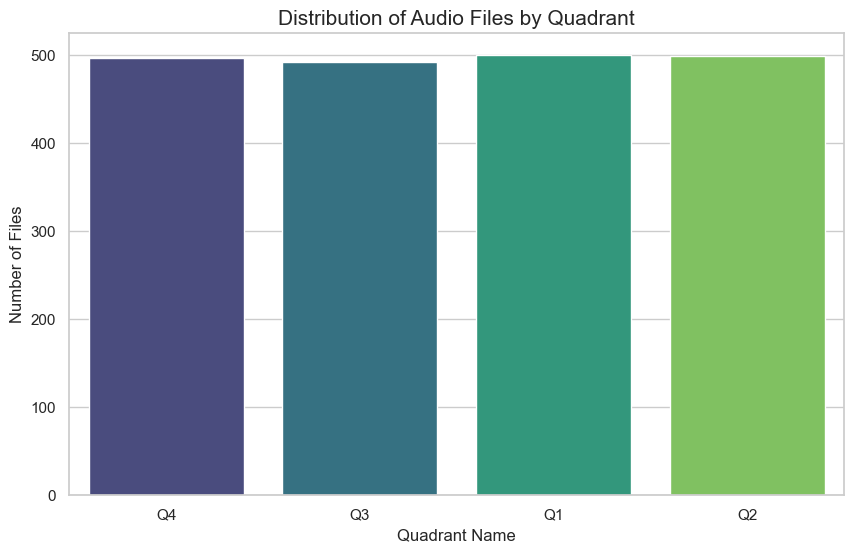

In [12]:
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Use countplot to automatically count and plot the data
sns.countplot(data=non_null_genres, x='Quadrant', palette='viridis', hue='Quadrant', legend=False)

# Add titles and labels
plt.title('Distribution of Audio Files by Quadrant', fontsize=15)
plt.xlabel('Quadrant Name', fontsize=12)
plt.ylabel('Number of Files', fontsize=12)

plt.show()

In [13]:
final_df = non_null_genres[["Audio_Song", "Lyric_Song", "Quadrant", "Genres"]]

In [14]:
final_df.head()

,Audio_Song,Lyric_Song,Quadrant,Genres
0,A001,L051,Q4,"Jazz,Vocal Jazz,Traditional Pop,Early Pop/Rock..."
1,A002,L052,Q4,Pop/Rock
2,A003,L053,Q3,"Soul,Pop-Soul,Smooth Soul,R&B"
3,A004,L054,Q3,"Outlaw Country,Country"
4,A005,L055,Q1,"Dance-Rock,R&B,Contemporary Pop/Rock,Contempor..."


In [15]:
from collections import Counter

In [16]:
def build_label_map(labels: pd.Series) -> dict[str, int]:
    """Map genre strings to integer indices, sorted by frequency (most common = 0)."""
    freq = Counter(labels.dropna())
    sorted_genres = [genre for genre, _ in freq.most_common()]
    return {genre: idx for idx, genre in enumerate(sorted_genres)}

In [17]:
label_map = build_label_map(final_df["Quadrant"])
final_df["label"] = final_df["Quadrant"].map(label_map)
label_map = build_label_map(final_df["Quadrant"])
final_df["label"] = final_df["Quadrant"].map(label_map)

In [18]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 1988 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Audio_Song  1988 non-null   str  
 1   Lyric_Song  1988 non-null   str  
 2   Quadrant    1988 non-null   str  
 3   Genres      1988 non-null   str  
 4   label       1988 non-null   int64
dtypes: int64(1), str(4)
memory usage: 93.2 KB


In [19]:
final_df = final_df.rename(columns={
    "Audio_Song": "audio_file_stem",
    "Lyric_Song": "lyric_file_stem",
    "Quadrant": "quadrant",
    "Genres": "genres"
})

In [20]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 1988 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   audio_file_stem  1988 non-null   str  
 1   lyric_file_stem  1988 non-null   str  
 2   quadrant         1988 non-null   str  
 3   genres           1988 non-null   str  
 4   label            1988 non-null   int64
dtypes: int64(1), str(4)
memory usage: 93.2 KB


In [21]:
from config import config

In [22]:
root = Path("../../..")

In [23]:
METADATA_DIR = root / config.METADATA_DIR

In [24]:
METADATA_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
final_df.to_csv(METADATA_DIR / "metadata_en.csv", index=False)